In [4]:
import pandas as pd
data=pd.read_csv("../data/House Price Prediction Dataset.csv",index_col=0)
#data2=pd.read_csv("../data/house_prices.csv")
  


In [5]:
data['Garage'] = data['Garage'].map({'Yes': 1, 'No': 0},inplace=True)
data['Condition']=data['Condition'].map({'Excellent':4,'Good':3,'Fair':2,'Poor':1},inplace=True)
#data['Location']=data['Location'].map({'Downtown'})



In [6]:
data['Price_normalize']=(data['Price']- data["Price"].min() /data['Price'].max()-data['Price'].min())
data['Family']=((data['Area']>2000) & (data['Bedrooms']>3)).astype(int)
data

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price,Price_normalize,Family
Id,,,,,,,,,,,
1,1360,5,4,3,1970,Downtown,4,0,149919,99913.949978,0
2,4272,5,4,3,1958,Downtown,4,0,424998,374992.949978,1
3,3592,2,2,3,1938,Downtown,3,0,266746,216740.949978,0
4,966,4,2,2,1902,Suburban,2,1,244020,194014.949978,0
5,4926,1,4,2,1975,Downtown,2,1,636056,586050.949978,0
...,...,...,...,...,...,...,...,...,...,...,...
1996,4994,5,4,3,1923,Suburban,1,0,295620,245614.949978,1
1997,3046,5,2,1,2019,Suburban,1,1,580929,530923.949978,1
1998,1062,5,1,2,1903,Rural,1,0,476925,426919.949978,0


In [7]:
#No null values detected

encoded_data = pd.get_dummies(
    data,
    columns=["Location"],
    drop_first=True
)
encoded_data


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Condition,Garage,Price,Price_normalize,Family,Location_Rural,Location_Suburban,Location_Urban
Id,,,,,,,,,,,,,
1,1360,5,4,3,1970,4,0,149919,99913.949978,0,False,False,False
2,4272,5,4,3,1958,4,0,424998,374992.949978,1,False,False,False
3,3592,2,2,3,1938,3,0,266746,216740.949978,0,False,False,False
4,966,4,2,2,1902,2,1,244020,194014.949978,0,False,True,False
5,4926,1,4,2,1975,2,1,636056,586050.949978,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,4994,5,4,3,1923,1,0,295620,245614.949978,1,False,True,False
1997,3046,5,2,1,2019,1,1,580929,530923.949978,1,False,True,False
1998,1062,5,1,2,1903,1,0,476925,426919.949978,0,True,False,False


In [8]:
#data.info()
#print(data[["price"],["Area"]].corr())
print(encoded_data.corr()["Price_normalize"].sort_values(ascending=False))


Price_normalize      1.000000
Price                1.000000
Floors               0.055890
Location_Suburban    0.040303
YearBuilt            0.004845
Garage               0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Family              -0.005054
Condition           -0.010576
Bathrooms           -0.015737
Location_Urban      -0.038312
Name: Price_normalize, dtype: float64


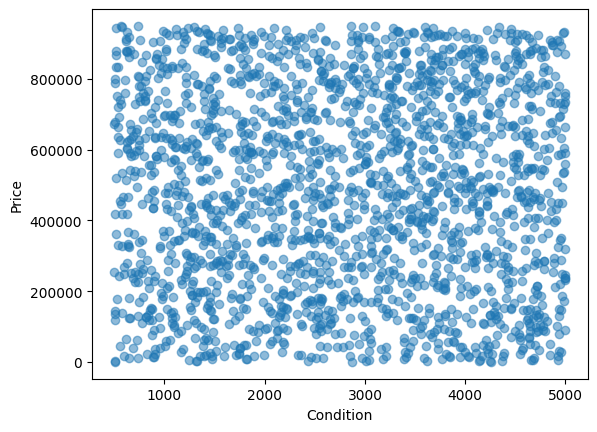

In [9]:
import matplotlib.pyplot as plt

plt.scatter(encoded_data["Area"], encoded_data["Price_normalize"],alpha=0.5)
plt.xlabel("Condition")
plt.ylabel("Price")
plt.show()

In [20]:
#encoded_data
#prepare Data for Training (test and spilt)
X=encoded_data.drop(["Price_normalize","Price"],axis=1)
y=encoded_data["Price_normalize"]
X.columns




Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Condition',
       'Garage', 'Family', 'Location_Rural', 'Location_Suburban',
       'Location_Urban'],
      dtype='str')

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
from sklearn.metrics import mean_absolute_error

prediction =model.predict(X_test)

mae=mean_absolute_error(y_test,prediction)
print(mae)


243581.89195673808


In [14]:
from sklearn.metrics import r2_score

r2=r2_score(y_test,prediction)
print(r2)

-0.009494453617426624


In [ ]:
#saving model 
import pickle 
pickle.dump(model,open("model_house_price_preduction.pkl","wb"))


In [21]:
import numpy as np
from fastapi import FastAPI


model=pickle.load(open("model_house_price_preduction.pkl","rb"))

app=FastAPI()

@app.post("/predict")
def predict(area:float , bedrooms:int, Bathrooms:int ,Floors:int ,YearBuilt:str,Condition:int,Garage:int,Family:int,Location_Rural:bool, Location_Suburban:bool,Location_Urban:bool):

    features = pd.DataFrame({
    "Area": [area],
    "Bedrooms": [bedrooms],
    "Bathrooms":[Bathrooms],
    "Floors":[Floors],
    "YearBuilt":[YearBuilt],
    "Condition":[Condition],
    "Garage":[Garage],
    "Family":[Family],
    "Location_Rural":[Location_Rural],
    "Location_Suburban":[Location_Suburban],
    "Location_Urban":[Location_Urban]
    })
    prediction=model.predict(features)
    
    return{
        "prediction price":prediction
    }

    # ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Condition',
    #    'Garage', 'Family', 'Location_Rural', 'Location_Suburban',
    #    'Location_Urban']

ModuleNotFoundError: No module named 'fastapi'